ANALISI ESPLORATIVA DEI DATI

Caricamento e osservazione del dataset:

Abbiamo usato .parquet invece che .csv perchè -parquet è più veloce e compresso e permette la gestione di grandi dataset. 

Quando il dataset contiene colonne con tipi avanzati di pandas, fastparquet è più stabile per leggere i file Parquet in Jupyter.

In [3]:
import pandas as pd

# Percorso del file Parquet
file_path = r"../data/github_issues_dataset.parquet"

# Leggere il file
df = pd.read_parquet(file_path, engine='fastparquet')

# Visualizzare le prime righe del dataset
df.head()

,id,repo,title,body,labels,priority,severity
0,393061,youtube-dl,Output file size with -s or -g,Was: http://bitbucket.org/rg3/youtube-dl/issue...,request,medium,Critical
1,1637737,youtube-dl,Create a php API and demo page,youtube-dl is often embedded by php applicatio...,php,low,Major
2,1639054,youtube-dl,"integrate template ""special sequences"" in help...",like in http://rg3.github.com/youtube-dl/docum...,request,low,Minor
3,1789251,youtube-dl,Add a path option to --keep-video,"Hey there,\n\nI think it would be a great idea...",request,low,Minor
4,1789512,youtube-dl,add support for picasaweb.google.com video clips,> /opt/local/bin/youtube-dl -t https://picasaw...,site-support-request,low,Minor


Controllo tipi di dati e i valori mancanti

In [4]:
# Visualizzare i tipi di dati
print("Tipi di dati per colonna:")
print(df.dtypes)

# Contare i valori mancanti per colonna
print("\nValori mancanti per colonna:")
print(df.isnull().sum())

Tipi di dati per colonna:
id           int64
repo        object
title       object
body        object
labels      object
priority    object
severity    object
dtype: object

Valori mancanti per colonna:
id            0
repo          0
title         0
body        133
labels        0
priority      0
severity      0
dtype: int64


Il dataset è quasi completo.
L’unica colonna con valori mancanti è body, che ha 133 celle vuote su tutte le righe.
Questo significa che alcune issue non hanno una descrizione testuale.

Pulizia del dataset:

Eliminazione delle colonne con feature non rilevanti per il nostro scopo (Id, repo, priority, severity). 

Non eliminiamo i valori vuoti del body perchè nel mondo reale ci saranno issue senza descrizione, e il modello deve saper gestire quei casi. 

In [5]:
df = df[['title', 'body', 'labels']].copy()
print(df.shape)
df.head()

(114073, 3)


,title,body,labels
0,Output file size with -s or -g,Was: http://bitbucket.org/rg3/youtube-dl/issue...,request
1,Create a php API and demo page,youtube-dl is often embedded by php applicatio...,php
2,"integrate template ""special sequences"" in help...",like in http://rg3.github.com/youtube-dl/docum...,request
3,Add a path option to --keep-video,"Hey there,\n\nI think it would be a great idea...",request
4,add support for picasaweb.google.com video clips,> /opt/local/bin/youtube-dl -t https://picasaw...,site-support-request


Controllo colonna labels prima di fare mapping perchè vogliamo vedere il format(Stringe/Lista) e capire come con cosa stiamo lavorando.

In [6]:
# vedi i primi 20 valori unici per capire il formato
print(df['labels'].value_counts().head(20))

labels
bug                                    2380
NeedsInvestigation                     1869
Suggestion,Awaiting More Feedback      1195
bug-report                             1137
enhancement                            1072
Needs-Triage                            940
site-support-request                    691
Issue-Bug,Needs-Triage                  636
Bug                                     613
oncall: jit                             607
needs triage,issue: bug report          557
A-diagnostics,T-compiler                543
Proposal                                518
feature request                         511
NeedsInvestigation,compiler/runtime     478
bug,topic:editor                        455
request                                 420
Suggestion,In Discussion                406
bug,needs triage                        398
Needs Investigation                     371
Name: count, dtype: int64


Mappiamo tutte le possibili labels in 3 grandi classi

In [7]:
def map_label(label_str):
    label_str = str(label_str).lower()
    if 'bug' in label_str:
        return 'bug'
    elif 'enhancement' in label_str or 'feature' in label_str or 'request' in label_str:
        return 'feature'
    elif 'question' in label_str or 'help' in label_str:
        return 'question'
    else:
        return None  # issue con label non classificabile

df['label'] = df['labels'].apply(map_label)

# rimuovi le righe senza label chiara
df = df.dropna(subset=['label'])
print(df.shape)
print(df['label'].value_counts())

(59826, 4)
label
bug         34048
feature     23322
question     2456
Name: count, dtype: int64


Distribuzione delle classi

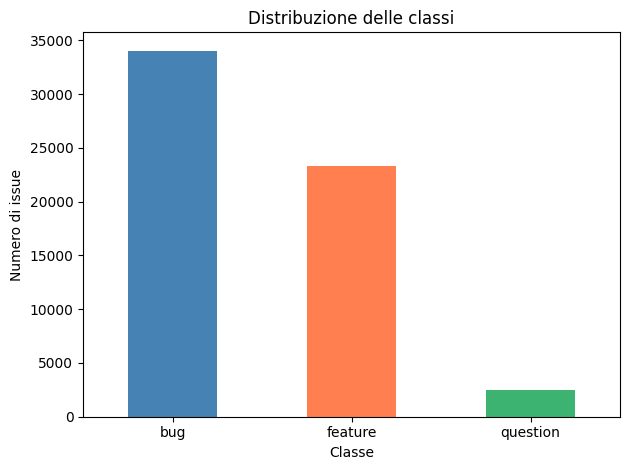

In [10]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar', color=['steelblue', 'coral', 'mediumseagreen'])
plt.title('Distribuzione delle classi')
plt.xlabel('Classe')
plt.ylabel('Numero di issue')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../figures/class_distribution.png')
plt.show()

La distribuzione delle classi risulta fortemente sbilanciata.

Le question sono considerate rumore quindi andiamo a eliminarle e il nostro problema diventa di tipo binario.

Andiamo anche a bilanciare il numero di bug/feature.

In [11]:
# Rimuoviamo eventuali NaN (sicurezza)
df_clean = df.dropna(subset=['label']).copy()

print("Distribuzione iniziale:")
print(df_clean['label'].value_counts())

# Rimuoviamo la classe 'question'
df_binary = df_clean[df_clean['label'] != 'question'].copy()

print("\nDopo rimozione question:")
print(df_binary['label'].value_counts())

Distribuzione iniziale:
label
bug         34048
feature     23322
question     2456
Name: count, dtype: int64

Dopo rimozione question:
label
bug        34048
feature    23322
Name: count, dtype: int64


In [12]:
# numero minimo di campioni per classe
min_class_size = df_binary['label'].value_counts().min()

# downsampling
df_balanced = (
    df_binary
    .groupby('label', group_keys=False)
    .sample(n=min_class_size, random_state=42)
    .reset_index(drop=True)
)

print("Distribuzione finale:")
print(df_balanced['label'].value_counts())

Distribuzione finale:
label
bug        23322
feature    23322
Name: count, dtype: int64


Unificazione del testo e lunghezza media 

In [13]:
# Uniamo titolo e corpo della issue
df_balanced['text'] = (
    df_balanced['title'].fillna('') + " " +
    df_balanced['body'].fillna('')
)

# Calcolo numero di parole
df_balanced['num_words'] = df_balanced['text'].str.split().str.len()

print(df_balanced[['text', 'num_words']].head())

                                                text  num_words
0  Resized Viewports don’t appear properly in the...        252
1  ImageSource in Image doesn't send headers ### ...        266
2  Viewport node doesn't display configuration wa...        204
3  Listener or rule for flutter_driver tests, to ...        107
4  Do not allow two plugins with the same name As...         45


In [14]:
print("Statistiche descrittive della lunghezza dei testi per classe:")

print(
    df_balanced.groupby('label')['num_words'].describe()
)

Statistiche descrittive della lunghezza dei testi per classe:
           count       mean         std  min    25%    50%    75%      max
label                                                                     
bug      23322.0  278.57062  366.807491  3.0  123.0  197.0  311.0  13136.0
feature  23322.0  193.00313  281.538446  2.0   77.0  136.0  234.0  18485.0


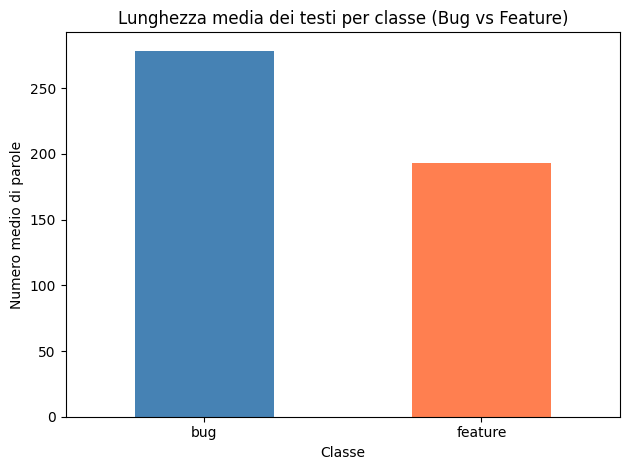

In [15]:
import matplotlib.pyplot as plt

df_balanced.groupby('label')['num_words'].mean().plot(
    kind='bar',
    color=['steelblue', 'coral']
)

plt.title('Lunghezza media dei testi per classe (Bug vs Feature)')
plt.xlabel('Classe')
plt.ylabel('Numero medio di parole')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

Facciamo uno splitting per creare train e test set, con un proporzione di 70/30

In [18]:
from sklearn.model_selection import train_test_split

# FEATURES (input del modello)
X = df_balanced['text']

# LABEL (output da predire)
y = df_balanced['label']

# Split 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Controllo dimensioni
print("Dataset split completato ✔")
print(f"Train set: {X_train.shape[0]} esempi")
print(f"Test set: {X_test.shape[0]} esempi")

Dataset split completato ✔
Train set: 32650 esempi
Test set: 13994 esempi


Salviamo il Dataset pulito


In [19]:
import pandas as pd

# Creo dataframe per train
train_df = pd.DataFrame({
    'text': X_train,
    'label': y_train
})

# Creo dataframe per test
test_df = pd.DataFrame({
    'text': X_test,
    'label': y_test
})

# Salvataggio su file CSV
train_df.to_csv("../data/train_set.csv", index=False)
test_df.to_csv("../data/test_set.csv", index=False)

print("Dataset salvati con successo ✔")
print("File creati:")
print("- train_set.csv")
print("- test_set.csv")

Dataset salvati con successo ✔
File creati:
- train_set.csv
- test_set.csv
